In [5]:
# !pip install pandas numpy sklearn seaborn
import pandas as pd

In [6]:
# %pip install pandas
# import pandas as pd
# print(pd.__version__)


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


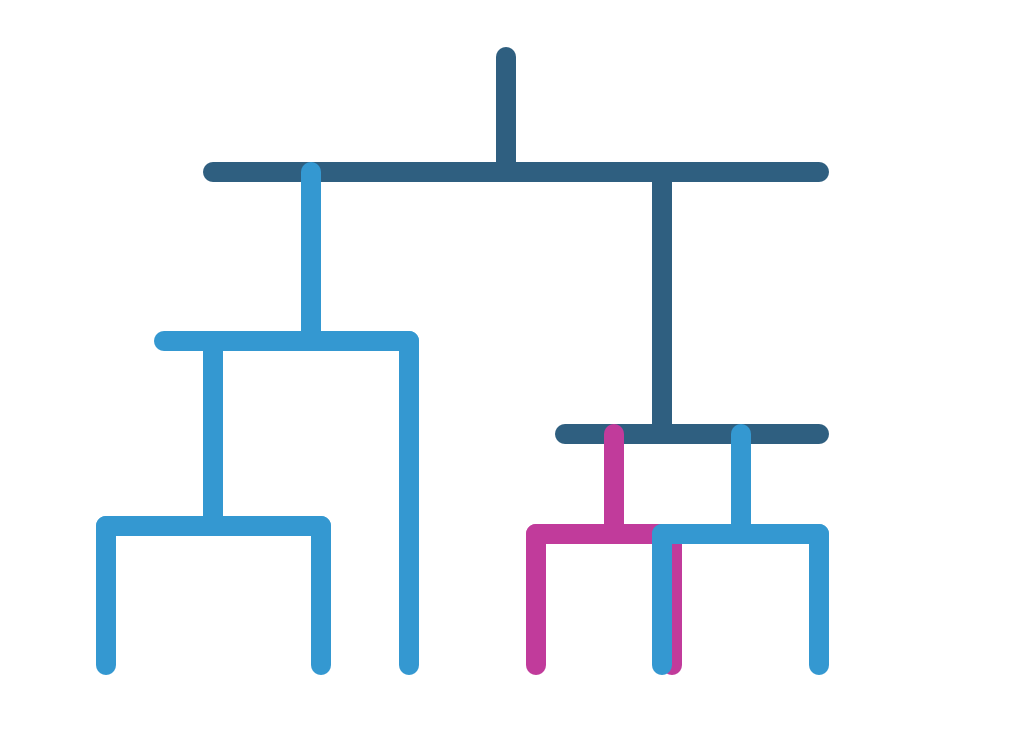

In [11]:
%pip install matplotlib
import matplotlib.pyplot as plt

# Colors close to your example
blue_dark = "#2f5f80"
blue_light = "#3498d1"
magenta = "#c13b9b"

# Use an even line width and higher DPI for cleaner branch junctions.
fig, ax = plt.subplots(figsize=(7, 5), dpi=180)
lw = 8

def seg(x1, y1, x2, y2, c):
    ax.plot(
        [x1, x2], [y1, y2],
        color=c, lw=lw, solid_capstyle="round", solid_joinstyle="round", antialiased=True
    )

# Root and first split
seg(0.50, 0.95, 0.50, 0.80, blue_dark)
seg(0.20, 0.80, 0.82, 0.80, blue_dark)

# Left major branch
seg(0.30, 0.80, 0.30, 0.58, blue_light)
seg(0.15, 0.58, 0.40, 0.58, blue_light)

# Left lower branch
seg(0.20, 0.58, 0.20, 0.34, blue_light)
seg(0.09, 0.34, 0.31, 0.34, blue_light)
seg(0.09, 0.34, 0.09, 0.16, blue_light)
seg(0.31, 0.34, 0.31, 0.16, blue_light)

# Long left terminal
seg(0.40, 0.58, 0.40, 0.16, blue_light)

# Right major branch
seg(0.66, 0.80, 0.66, 0.46, blue_dark)
seg(0.56, 0.46, 0.82, 0.46, blue_dark)

# Highlighted magenta terminal
seg(0.61, 0.46, 0.61, 0.33, magenta)
seg(0.53, 0.33, 0.67, 0.33, magenta)
seg(0.53, 0.33, 0.53, 0.16, magenta)
seg(0.67, 0.33, 0.67, 0.16, magenta)

# Right blue terminal
seg(0.74, 0.46, 0.74, 0.33, blue_light)
seg(0.66, 0.33, 0.82, 0.33, blue_light)
seg(0.66, 0.33, 0.66, 0.16, blue_light)
seg(0.82, 0.33, 0.82, 0.16, blue_light)

ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1.0)
ax.axis("off")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


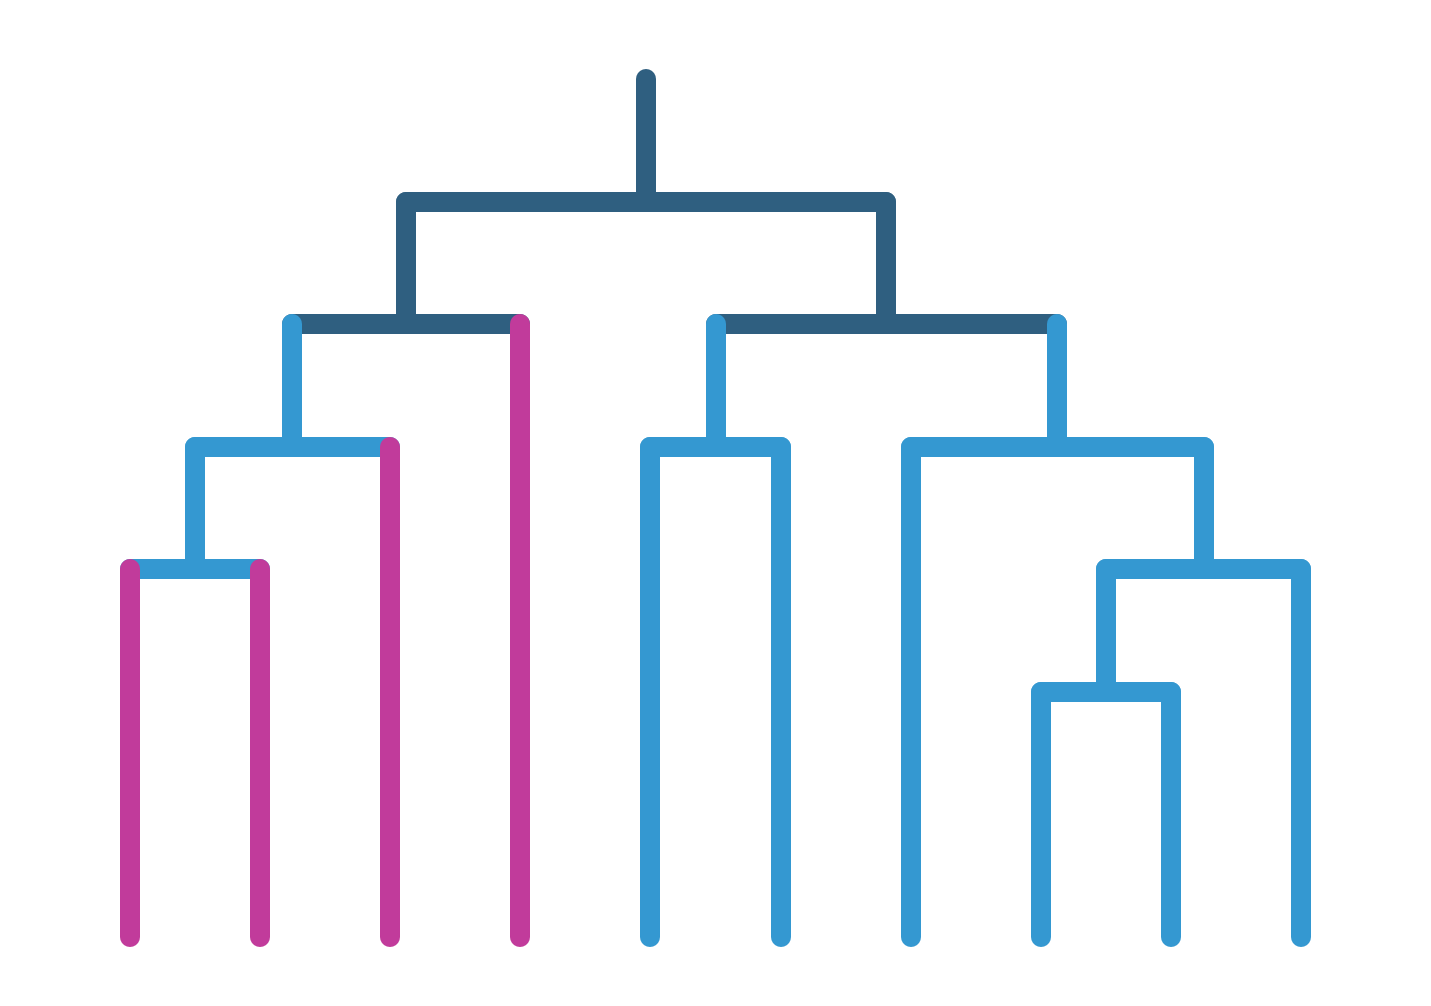

In [ ]:
%pip install networkx matplotlib
import random
import networkx as nx
import matplotlib.pyplot as plt

def random_binary_tree_styled(n_leaves=10, seed=12, highlight=True):
    """Generate a random bifurcating tree with NetworkX and render in a similar style."""
    rng = random.Random(seed)

    # Build a random rooted binary tree by repeatedly merging two active nodes.
    rooted = nx.DiGraph()
    leaves = [f"L{i}" for i in range(n_leaves)]
    rooted.add_nodes_from(leaves)
    active = leaves[:]
    next_id = 0

    while len(active) > 1:
        a, b = rng.sample(active, 2)
        active.remove(a)
        active.remove(b)
        p = f"I{next_id}"
        next_id += 1
        rooted.add_node(p)
        rooted.add_edge(p, a)
        rooted.add_edge(p, b)
        # Random child order for varied shapes
        if rng.random() < 0.5:
            rooted.remove_edge(p, a)
            rooted.remove_edge(p, b)
            rooted.add_edge(p, b)
            rooted.add_edge(p, a)
        active.append(p)

    root = active[0]

    # Undirected NetworkX tree version (if you need standard tree algorithms).
    T = rooted.to_undirected()

    children = {u: list(rooted.successors(u)) for u in rooted.nodes()}
    depth = {root: 0}
    for u in nx.topological_sort(rooted):
        for v in children[u]:
            depth[v] = depth[u] + 1

    # Compact hierarchical x positions: leaves left->right, internals centered.
    x = {}
    leaf_order = [n for n in nx.dfs_preorder_nodes(rooted, source=root) if not children[n]]
    for i, leaf in enumerate(leaf_order):
        x[leaf] = i

    def assign_internal_x(u):
        ch = children[u]
        if not ch:
            return x[u]
        vals = [assign_internal_x(v) for v in ch]
        x[u] = sum(vals) / len(vals)
        return x[u]

    assign_internal_x(root)
    max_x = max(x.values()) if x else 1
    x = {k: 0.08 + 0.84 * (v / max_x if max_x else 0.5) for k, v in x.items()}

    max_depth = max(depth.values()) if depth else 1
    y = {k: 0.92 - 0.60 * (depth[k] / max_depth if max_depth else 0) for k in depth}
    tip_y = 0.08

    # Highlight one random internal clade in magenta.
    highlight_edges = set()
    highlight_nodes = set()
    if highlight:
        internal = [u for u in rooted.nodes() if children[u]]
        if internal:
            h = rng.choice(internal)
            stack = [h]
            while stack:
                u = stack.pop()
                highlight_nodes.add(u)
                for v in children[u]:
                    highlight_edges.add((u, v))
                    stack.append(v)

    blue_dark = "#2f5f80"
    blue_light = "#3498d1"
    magenta = "#c13b9b"
    orange = "#e67e22"
    lw = 12

    fig, ax = plt.subplots(figsize=(10, 7), dpi=180)

    def seg(x1, y1, x2, y2, c):
        ax.plot(
            [x1, x2], [y1, y2],
            color=c, lw=lw, solid_capstyle="round", solid_joinstyle="round"
        )

    # Draw each internal node as a classic bifurcation: trunk, bar, two drops.
    for u in nx.topological_sort(rooted):
        ch = children[u]
        if not ch:
            continue

        y_split = sum(y[v] for v in ch) / len(ch)
        x_left, x_right = sorted([x[ch[0]], x[ch[1]]])
        trunk_color = blue_dark if depth[u] <= 1 else blue_light

        seg(x[u], y[u], x[u], y_split, trunk_color)
        seg(x_left, y_split, x_right, y_split, trunk_color)

        for v in ch:
            c = magenta if (u, v) in highlight_edges else blue_light
            seg(x[v], y_split, x[v], y[v], c)

    # Extend every terminal branch to the same depth (ultrametric-style tips).
    for leaf in leaves:
        leaf_color = magenta if leaf in highlight_nodes else blue_light
        seg(x[leaf], y[leaf], x[leaf], tip_y, leaf_color)

    ax.set_xlim(0, 1)
    ax.set_ylim(0.03, 0.98)
    ax.axis("off")
    plt.show()

    return T, rooted

# Example: each run with a new seed gives a different random bifurcating tree
T, rooted = random_binary_tree_styled(n_leaves=10, seed=12, highlight=True)

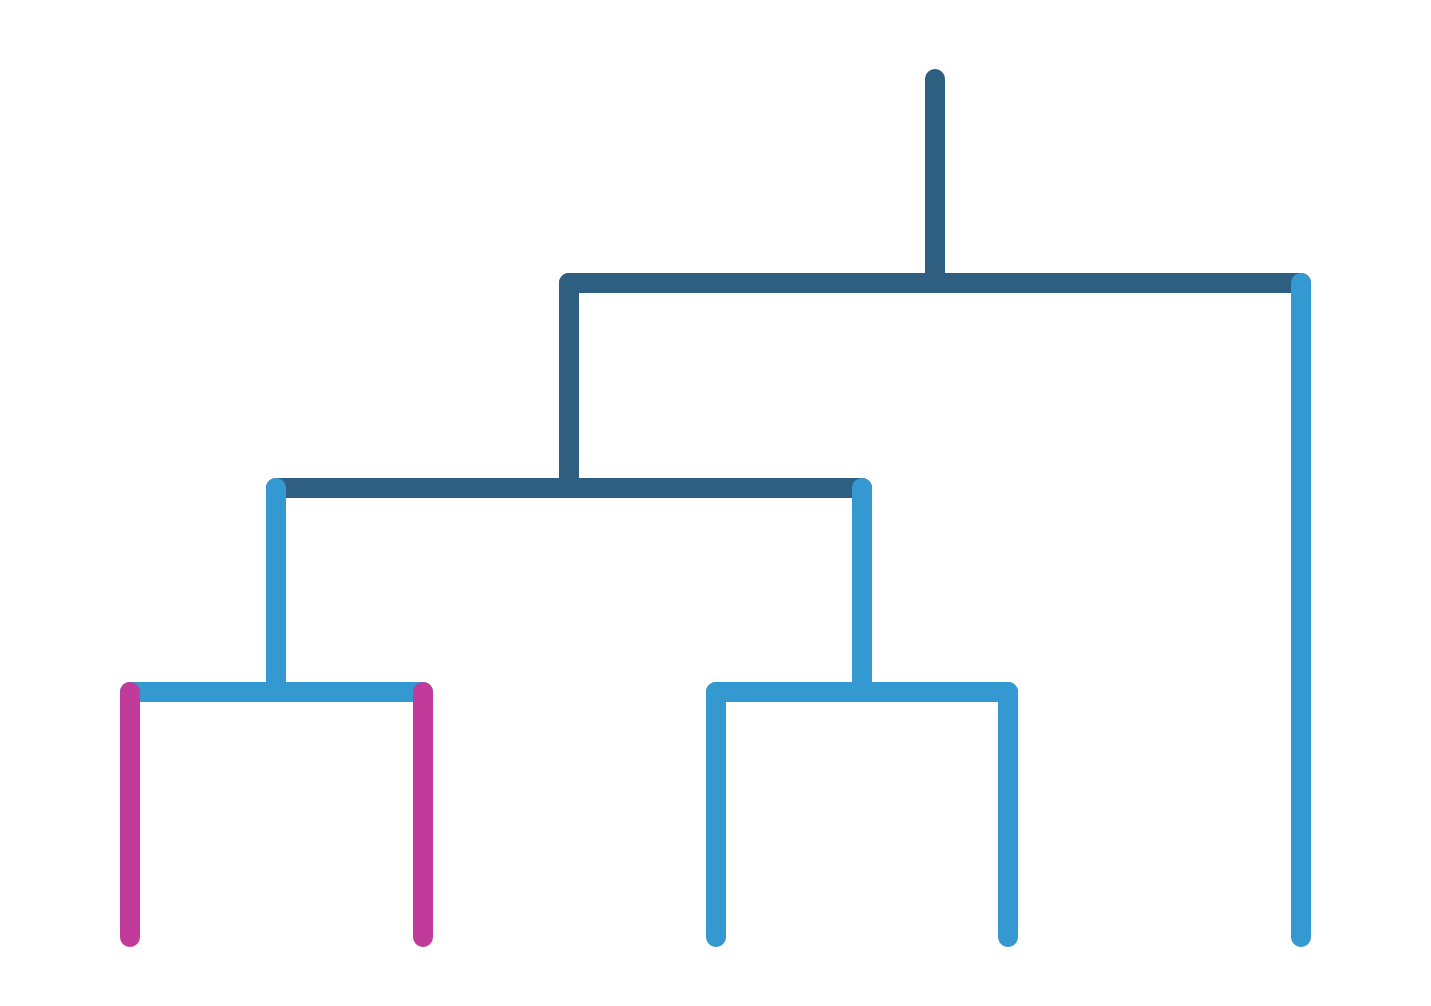

In [18]:
T, rooted = random_binary_tree_styled(n_leaves=5, seed=12, highlight=True)